## Setup & Data Quality Check
Load the raw transaction data, inspect it, and check for missing values, duplicates, and invalid amounts.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# 1. تحميل البيانات
df = pd.read_csv('01-ml-project/retail_transactions_segmentation.csv')

# 2. عرض أول 5 صفوف
print("--- Data Head ---")
display(df.head())

print("\n--- Data Info ---")
df.info()

print("\n--- Missing Values & Duplicates ---")
print("Missing values per column:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# 3. معالجة وتجهيز أنواع البيانات
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

# الاحصاءيات
print("\n--- Statistical Summary (Numeric Columns)---")
display(df.drop(columns=['customer_id']).describe(include=[np.number]))
#التاكد من عدم وجود قيم سالبه في عمود المبلغ
print(' Check for negative values in the amount column:', (df['amount']<0).sum())

--- Data Head ---


,customer_id,transaction_date,amount,product_category
0,5206,2024-01-31,162.65,Fashion
1,5153,2024-07-03,389.85,Fashion
2,5102,2024-11-13,453.72,Home & Living
3,5073,2024-03-11,824.74,Electronics
4,5097,2024-12-28,181.74,Sports



--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3663 entries, 0 to 3662
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_id       3663 non-null   int64  
 1   transaction_date  3663 non-null   object 
 2   amount            3663 non-null   float64
 3   product_category  3663 non-null   object 
dtypes: float64(1), int64(1), object(2)
memory usage: 114.6+ KB

--- Missing Values & Duplicates ---
Missing values per column:
 customer_id         0
transaction_date    0
amount              0
product_category    0
dtype: int64

Duplicate rows: 0

--- Statistical Summary (Numeric Columns)---


,amount
count,3663.000000
mean,513.028376
std,305.332100
min,5.000000
25%,276.550000
50%,411.870000
75%,767.740000
max,1506.360000


 Check for negative values in the amount column: 0


## Point 1 — RFM Feature Table
Build the customer-level Recency, Frequency, and Monetary table from the raw transactions.

In [ ]:


#تحديد تاريخ مرجعي ثابت (بناخد يوم بعد اخر تاريخ شراء علشان نحسب منه العميل غايب بقاله قد اي
snapshot_date = df['transaction_date'].max() + pd.Timedelta(days=1)

# تجميع البيانات على مستوى العملاء لحساب RFM
rfm = df.groupby('customer_id').agg({
    'transaction_date': lambda x: (snapshot_date - x.max()).days,
    'customer_id': 'count',
    'amount': 'sum'
}).rename(columns={
    'transaction_date': 'Recency',
    'customer_id': 'Frequency',
    'amount': 'Monetary'
})

print("RFM Table Shape:", rfm.shape)
rfm.head()

RFM Table Shape: (300, 3)


,Recency,Frequency,Monetary
customer_id,,,
5001,2,16,5172.45
5002,23,18,6158.98
5003,37,3,654.12
5004,5,35,31050.88
5005,26,16,5700.91


## Point 2 — Feature Scaling
Standardize the RFM features before clustering.

In [ ]:
rfm_features=['Recency','Frequency','Monetary']
scaler=StandardScaler()
rfm_scaled=scaler.fit_transform(rfm[rfm_features])

#تحويل القيم بعد ال scalingلجدول علشان نعرف نتعامل معاها بسهوله
rfm_scaled_df=pd.DataFrame(rfm_scaled, columns=rfm_features , index=rfm.index)
rfm_scaled_df.head()

,Recency,Frequency,Monetary
customer_id,,,
5001,-0.772792,0.356692,-0.113196
5002,-0.464634,0.544920,-0.010898
5003,-0.259195,-0.866790,-0.581723
5004,-0.728770,2.144859,2.570262
5005,-0.420611,0.356692,-0.058397


## Point 3 — Choosing k (Elbow Method & Silhouette Score)
Sweep k from 2 to 10 and evaluate both diagnostics to justify the chosen k.

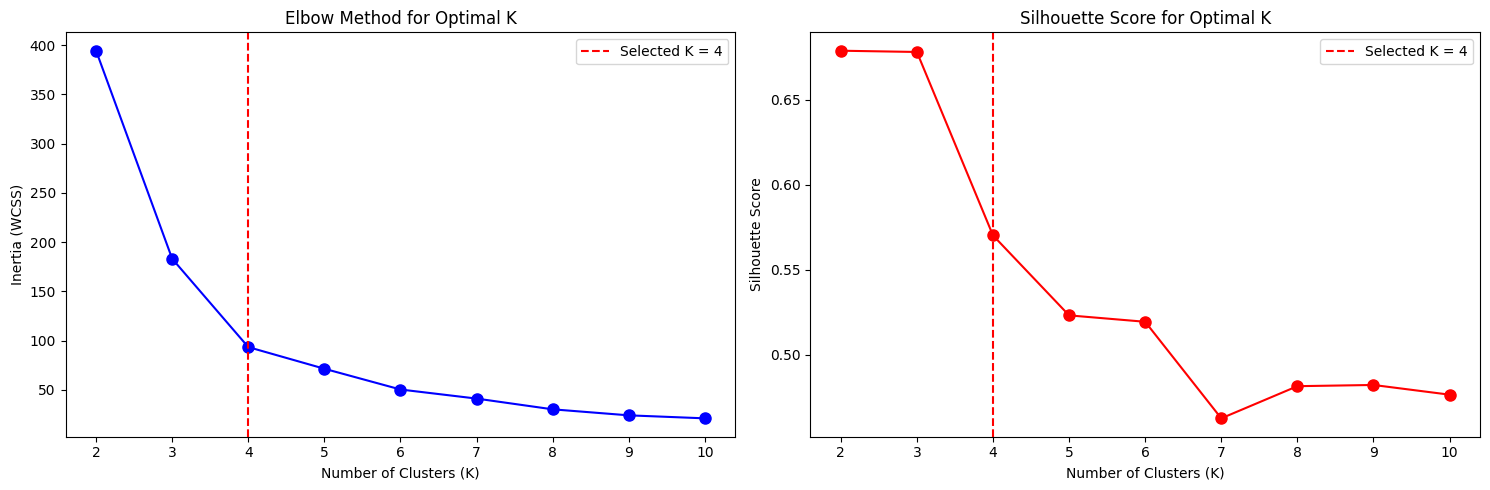

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 1. حساب الـ Inertia والـ Silhouette Score للقيم من 2 إلى 10
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))

# 2. رسم الـ Elbow Method و Silhouette Score جنب بعض
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# رسمة الـ Elbow
ax[0].plot(K_range, inertia, 'bo-', markersize=8)
ax[0].axvline(x=4, color='r', linestyle='--', label='Selected K = 4')
ax[0].set_title('Elbow Method for Optimal K')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('Inertia (WCSS)')
ax[0].set_xticks(K_range)
ax[0].legend()

# رسمة الـ Silhouette Score
ax[1].plot(K_range, silhouette_scores, 'ro-', markersize=8)
ax[1].axvline(x=4, color='r', linestyle='--', label='Selected K = 4')
ax[1].set_title('Silhouette Score for Optimal K')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].set_xticks(K_range)
ax[1].legend()

plt.tight_layout()
plt.show()



## Point 4 — Fit K-Means (k = 4)

In [ ]:
# تدريب K-Means بـ k=4
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

rfm.head()

,Recency,Frequency,Monetary,Cluster
customer_id,,,,
5001,2,16,5172.45,3
5002,23,18,6158.98,3
5003,37,3,654.12,0
5004,5,35,31050.88,1
5005,26,16,5700.91,3


## Point 5 — PCA Visualization & Point 6 — Cluster Profiling

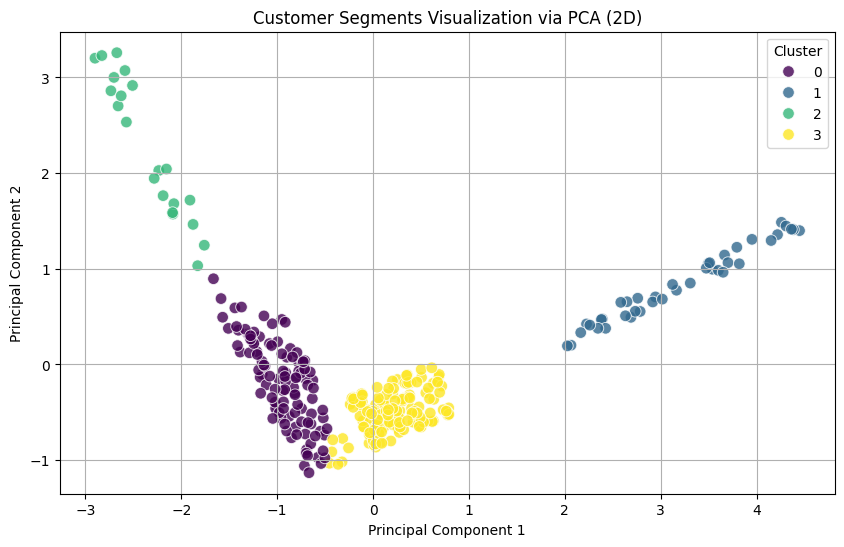

=== Cluster Summary (Mean Values) ===
         Recency  Frequency  Monetary
Cluster                              
0          71.57       4.23    752.49
1           8.40      35.00  29683.61
2         263.38       2.10    320.48
3          20.22      13.67   4700.17


In [ ]:
# =========================================================
# Step 5: Visualize with PCA (2D Plot)
# =========================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
rfm_pca = pca.fit_transform(rfm_scaled)

rfm['PCA1'] = rfm_pca[:, 0]
rfm['PCA2'] = rfm_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=rfm,
    palette='viridis',
    s=70,
    alpha=0.8,
)
plt.title('Customer Segments Visualization via PCA (2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

# =========================================================
# Step 6: Cluster Profiling (Calculate RFM Averages)
# =========================================================
cluster_profile = (
    rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']]
        .mean()
        .round(2)
)
print("=== Cluster Summary (Mean Values) ===")
print(cluster_profile)


## Point 6 — Persona Table & Bonus: Product Category Mix
Mean RFM values per cluster, plus an extra breakdown of product-category share per persona.

In [ ]:
# جدول متوسطات RFM لكل كلاستر
cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Customer_Count'}).reset_index()
display(cluster_summary.round(2))

# دمج تصنيف الكلاستر مع المعاملات لمعرفة الفئات المشتراة
df_merged = df.merge(rfm[['Cluster']], on='customer_id')
category_summary = pd.crosstab(df_merged['Cluster'], df_merged['product_category'], normalize='index') * 100
display(category_summary.round(1))

,Cluster,Recency,Frequency,Monetary,Customer_Count
0,0,71.57,4.23,752.49,111
1,1,8.40,35.00,29683.61,40
2,2,263.38,2.10,320.48,21
3,3,20.22,13.67,4700.17,128


product_category,Beauty,Electronics,Fashion,Groceries,Home & Living,Sports
Cluster,,,,,,
0,14.1,17.7,16.6,19.0,16.2,16.4
1,17.3,15.3,15.1,17.3,17.1,18.0
2,11.4,18.2,20.5,13.6,18.2,18.2
3,15.9,16.3,17.3,17.3,16.5,16.7


## Point 6 — Persona Descriptions (Naming the Personas)

## تفسير وتصنيف شرائح العملاء

بناءً على جدول متوسطات **RFM** لكل Cluster، يمكن تقسيم العملاء إلى أربع شرائح رئيسية:

###  Cluster 1 — العملاء المميزون (VIP / Champions)

**40 عميلًا**، بمتوسط:

* **Recency ≈ 7 أيام**
* **Frequency ≈ 35 عملية شراء**
* **Monetary ≈ 29,684 جنيه مصري**

تُعد هذه الفئة **أكثر العملاء قيمة للشركة بفارق كبير**. فهم يشترون بشكل متكرر، وكانت آخر عملية شراء لهم حديثة جدًا، بالإضافة إلى أن إجمالي إنفاقهم أعلى بكثير من باقي الفئات.

**الاستراتيجية المقترحة:**
يجب الحفاظ على هذه الفئة والاهتمام بها بشكل خاص، من خلال منحهم وصولًا مبكرًا للمنتجات الجديدة، وتقديم مستوى مميز من برامج الولاء، بالإضافة إلى التواصل الشخصي معهم إذا بدأ نشاطهم في الانخفاض.

---

###  Cluster 3 — العملاء المنتظمون والمواليون (Loyal Regulars)

**128 عميلًا**، بمتوسط:

* **Recency ≈ 19 يومًا**
* **Frequency ≈ 14 عملية شراء**
* **Monetary ≈ 4,700 جنيه مصري**

تمثل هذه الفئة **أكبر شريحة من العملاء**. وهم عملاء منتظمون يشترون بشكل متكرر وحديث نسبيًا، مما يجعلهم مصدرًا مستقرًا للإيرادات.

**الاستراتيجية المقترحة:**
تُعد هذه الفئة الأنسب لعمليات **Upselling** والعروض التي تجمع بين فئات منتجات مختلفة، بهدف زيادة قيمة مشترياتهم وتشجيعهم على الانتقال تدريجيًا إلى فئة العملاء المميزين (VIP).

---

###  Cluster 0 — العملاء المعرضون لفقدانهم (At-Risk)

**111 عميلًا**، بمتوسط:

* **Recency ≈ 71 يومًا**
* **Frequency ≈ 4 عمليات شراء**
* **Monetary ≈ 753 جنيه مصري**

هؤلاء العملاء قاموا بآخر عملية شراء منذ أكثر من شهرين في المتوسط، كما أن معدل شرائهم منخفض نسبيًا، مما يشير إلى أن **تفاعلهم مع الشركة بدأ في الانخفاض**.

**الاستراتيجية المقترحة:**
هذه الفئة هي الأنسب لحملات **Win-Back** في الوقت الحالي، مثل تقديم كود خصم أو إرسال رسالة "نفتقدك"، بهدف إعادة تنشيط العملاء قبل أن ينتقلوا إلى فئة العملاء غير النشطين (Dormant).

---

###  Cluster 2 — العملاء غير النشطين (Dormant)

**21 عميلًا**، بمتوسط:

* **Recency ≈ 262 يومًا**
* **Frequency ≈ 2 عملية شراء**
* **Monetary ≈ 320 جنيه مصري**

هذه الفئة هي **الأقل نشاطًا**؛ حيث مر ما يقارب تسعة أشهر في المتوسط منذ آخر عملية شراء، بالإضافة إلى انخفاض عدد عمليات الشراء وإجمالي الإنفاق.

**الاستراتيجية المقترحة:**
لا يُنصح بتخصيص ميزانية تسويقية كبيرة لهذه الفئة، لأن العائد المتوقع من حملات إعادة تنشيطهم منخفض نسبيًا. ويمكن بدلًا من ذلك استخدام وسائل منخفضة التكلفة، مثل إرسال عروض موسمية أو رسائل بريد إلكتروني بسيطة لإعادة جذبهم.

---

###  ملاحظة مهمة

أرقام الـ **Clusters (0, 1, 2, 3)** التي يقوم نموذج **K-Means** بتعيينها هي أرقام عشوائية، وقد تختلف من تشغيل إلى آخر أو من نموذج إلى آخر.

لذلك، **الأهم ليس رقم الـCluster نفسه، وإنما خصائص العملاء الموجودة بداخله**، والتي يتم تحديدها من خلال متوسطات:

* **Recency** → مدى حداثة آخر عملية شراء.
* **Frequency** → عدد مرات الشراء.
* **Monetary** → إجمالي قيمة المشتريات.

وبناءً على هذه القيم تم تحديد شخصية كل مجموعة: **VIP / Champions، Loyal Regulars، At-Risk، Dormant**.
